In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Import our visualization functions
# from plotting_utils import (
#     plot_gp_1d, plot_acquisition_1d, plot_bo_iteration_1d,
#     plot_2d_function, plot_2d_bo_state, plot_convergence,
#     plot_parallel_coordinates
# )

# Set random seed for reproducibility
np.random.seed(42)
# plt.style.use('seaborn-v0_8-darkgrid')

/Users/martindufour/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Function 1
print('Function 1')
func1_inputs = np.load('./initial_data/function_1/initial_inputs.npy')
print(func1_inputs)

func1_outputs = np.load('./initial_data/function_1/initial_outputs.npy')
print(func1_outputs)
print('/n')

# Function 2
print('Function 2')
func2_inputs = np.load('./initial_data/function_2/initial_inputs.npy')
print(func2_inputs)

func2_outputs = np.load('./initial_data/function_2/initial_outputs.npy')
print(func2_outputs)
print('/n')

# Function 3
print('Function 3')
func3_inputs = np.load('./initial_data/function_3/initial_inputs.npy')
print(func3_inputs)

func3_outputs = np.load('./initial_data/function_3/initial_outputs.npy')
print(func3_outputs)
print('/n')

# Function 4
print('Function 4')
func4_inputs = np.load('./initial_data/function_4/initial_inputs.npy')
print(func4_inputs)

func4_outputs = np.load('./initial_data/function_4/initial_outputs.npy')
print(func4_outputs)
print('/n')

# Function 5
print('Function 5')
func5_inputs = np.load('./initial_data/function_5/initial_inputs.npy')
print(func5_inputs)

func5_outputs = np.load('./initial_data/function_5/initial_outputs.npy')
print(func5_outputs)
print('/n')

# Function 6
print('Function 6')
func6_inputs = np.load('./initial_data/function_6/initial_inputs.npy')
print(func6_inputs)

func6_outputs = np.load('./initial_data/function_6/initial_outputs.npy')
print(func6_outputs)
print('/n')

# Function 7
print('Function 7')
func7_inputs = np.load('./initial_data/function_7/initial_inputs.npy')
print(func7_inputs)

func7_outputs = np.load('./initial_data/function_7/initial_outputs.npy')
print(func7_outputs)
print('/n')

# Function 8
print('Function 8')
func8_inputs = np.load('./initial_data/function_8/initial_inputs.npy')
print(func8_inputs)

func8_outputs = np.load('./initial_data/function_8/initial_outputs.npy')
print(func8_outputs)
print('/n')

Function 1
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]
/n
Function 2
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]
/n
Function 3
[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.219

In [3]:
# Week 1 Input and Output Data
week_1_inputs = [ np.array([0.155793, 0.528435]), np.array([0.224164, 0.812385]), np.array([0.830919, 0.158523, 0.528406]), np.array([0.912533, 0.052672, 0.771239, 0.219812]), np.array([0.234189, 0.83648 , 0.884484, 0.873516]), np.array([0.490808, 0.618683, 0.277824, 0.900494, 0.106596]), np.array([0.067896, 0.486672, 0.255422, 0.215118, 0.427428, 0.72097 ]), np.array([0.061447, 0.062956, 0.029929, 0.036786, 0.407935, 0.795055, 0.496307,0.888085]) ]
week_1_outputs = [np.float64(1.5311489892413605e-58), np.float64(0.04614596805685454), np.float64(-0.04591165123945737), np.float64(-24.387232512869755), np.float64(1049.4420694211206), np.float64(-0.849252655626155), np.float64(1.3793294734939503), np.float64(9.598780741169)]

week_2_inputs = [np.array([0.946399, 0.18731 ]), np.array([0.712637, 0.921564]), np.array([0.765104, 0.052672, 0.438597]), np.array([0.380965, 0.771701, 0.089479, 0.536968]), np.array([0.219189, 0.85148 , 0.874484, 0.883516]), np.array([0.114755, 0.697421, 0.354179, 0.887624, 0.589139]), np.array([0.070896, 0.484672, 0.259422, 0.216118, 0.427428, 0.72297 ]), np.array([0.062447, 0.061956, 0.030929, 0.035786, 0.408935, 0.794055, 0.497307, 0.887085])]
week_2_outputs = [np.float64(2.338449488843798e-206), np.float64(0.5728372778652475), np.float64(-0.10235480701941752), np.float64(-13.368584815829887), np.float64(1109.9883069580462), np.float64(-1.492909868264592), np.float64(1.3944037721068683), np.float64(9.598978827169)]

week_3_inputs = [np.array([0.583738, 0.706798]), np.array([0.699637, 0.928564]), np.array([0.123457, 0.876543, 0.5     ]), np.array([0.230785, 0.914568, 0.102938, 0.657322]), np.array([0.214189, 0.85648 , 0.869484, 0.888516]), np.array([0.051235, 0.987654, 0.43211 , 0.123457, 0.765432]), np.array([0.071896, 0.483672, 0.261422, 0.217118, 0.426428, 0.72497 ]), np.array([0.063447, 0.060956, 0.031929, 0.034786, 0.409935, 0.793055, 0.498307, 0.886085])]
week_3_outputs = [np.float64(9.817718646044271e-07), np.float64(0.49978778689465564), np.float64(-0.04054152149606349), np.float64(-21.112987453792396), np.float64(1132.5255136709882), np.float64(-2.4679805862566795), np.float64(1.4059619293543582), np.float64(9.599155713169)]

week_4_inputs = [np.array([0.867072, 0.913241]), np.array([0.83604 , 0.696071]), np.array([0.447658, 0.395195, 0.505344]), np.array([0.422706, 0.385497, 0.37529 , 0.410833]), np.array([0.157706, 0.912326, 0.830158, 0.925715]), np.array([0.275401, 0.      , 0.568079, 1.      , 0.121326]), np.array([0.124679, 0.389027, 0.389012, 0.23686 , 0.379036, 0.802247]), np.array([0.077447, 0.21029 , 0.114032, 0.159535, 0.695924, 0.531316,0.178973, 0.57168 ])]
week_4_outputs = [np.float64(-1.0508862613282513e-96), np.float64(0.20657541488475104), np.float64(-0.03229682155733878), np.float64(0.4964978124935766), np.float64(1445.380906735266), np.float64(-0.8152779914672599), np.float64(2.0217812896063525), np.float64(9.987130922543)]

week_5_inputs = [np.array([0.065052, 0.948886]), np.array([0.388677, 0.271349]), np.array([1.      , 0.136717, 0.850593]), np.array([0.908266, 0.239562, 0.144895, 0.489453]), np.array([0.115614, 0.955641, 0.820859, 0.938174]), np.array([0.568442, 0.      , 1.      , 1.      , 1.      ]), np.array([0.134015, 0.028783, 0.755137, 0.62031 , 0.70408 , 0.212964]), np.array([0.127008, 0.292876, 0.06967 , 0.277582, 0.553407, 0.547258,0.220835, 0.443146])]
week_5_outputs = [np.float64(2.0262778967114778e-283), np.float64(0.016418658339648333), np.float64(-0.054388754089278846), np.float64(-17.161465002411145), np.float64(1779.8600577462366), np.float64(-1.9906490554141107), np.float64(0.052467603616080494), np.float64(9.9149654065019)]

week_6_inputs = [np.array([0.17701 , 0.088703]), np.array([0.593592, 0.679102]), np.array([0.7536, 1.    , 1.    ]), np.array([0.370348, 0.379959, 0.430216, 0.444351]), np.array([0.169493, 0.556801, 0.936155, 0.69603 ]), np.array([0.366464, 0.316099, 1.      , 1.      , 0.      ]), np.array([0.123574, 0.270452, 0.482301, 0.208163, 0.330398, 0.872733]), np.array([0.3191  , 0.828915, 0.037008, 0.59627 , 0.230009, 0.120567,0.076953, 0.696289])]
week_6_outputs = [np.float64(-2.3725238219366144e-119), np.float64(0.06836721478932847), np.float64(-0.48310415434111403), np.float64(0.18076540708623456), np.float64(282.83820524691396), np.float64(-0.8214281898088153), np.float64(2.075605759888563), np.float64(8.8803427965834)]

In [4]:
# Define acquisition function for optimization
def acq_objective(X, y, gp, acquisition, kappa = 2.5, xi=0.01):
    X = X.reshape(1, -1)
    mu, sigma = gp.predict(X, return_std=True)
            
    if acquisition == 'ei':
        acq_val = expected_improvement(mu, sigma, y.max())
    else:
        acq_val = upper_confidence_bound(mu, sigma, kappa)
            
    return -acq_val  # Negative because we use the 'minimize' function later

def upper_confidence_bound(mu, sigma, kappa=2.5):
    """
    Upper Confidence Bound (UCB) acquisition function.
    
    UCB = mean + kappa * std
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation
    kappa : exploration parameter (higher = more exploration)
    """
    return mu + kappa * sigma


def expected_improvement(mu, sigma, y_best, xi=0.01):
    """
    Expected Improvement (EI) acquisition function.
    
    EI = E[max(f(x) - f(x_best), 0)]
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation  
    y_best : best observed value so far
    xi : exploration parameter
    """
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei


In [5]:
# Function 1
print('Function 1')
# Load inputs from previous run
# Loads initial data
week_0_func1_inputs = np.load('./initial_data/function_1/initial_inputs.npy')
week_0_func1_outputs = np.load('./initial_data/function_1/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func1_inputs.shape}')
print(f'Shape of initial output data: {week_0_func1_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[0]}')
print(f'Week 2 inputs: {week_2_inputs[0]}')
print(f'Week 3 inputs: {week_3_inputs[0]}')
print(f'Week 4 inputs: {week_4_inputs[0]}')
print(f'Week 5 inputs: {week_5_inputs[0]}')
print(f'Week 6 inputs: {week_6_inputs[0]}')

combined_func1_inputs = np.vstack([
    week_0_func1_inputs,
    week_1_inputs[0],
    week_2_inputs[0],
    week_3_inputs[0],
    week_4_inputs[0],
    week_5_inputs[0],
    week_6_inputs[0]
])
print(f'Number of input data points: {len(combined_func1_inputs)}')
print('Combined input data')
print(combined_func1_inputs)

# Load outputs from previous run
week_func1_output = week_1_outputs[0]
combined_func1_outputs = np.concatenate([
    week_0_func1_outputs,
    [week_1_outputs[0]],
    [week_2_outputs[0]],
    [week_3_outputs[0]],
    [week_4_outputs[0]],
    [week_5_outputs[0]],
    [week_6_outputs[0]]
])
print(f'Number of output data points: {len(combined_func1_outputs)}')
print('Combined output data')
print(combined_func1_outputs)




# ---------- FUNCTION 1: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
kernel = ConstantKernel(1.0) * RBF(length_scale=(0.5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func1_inputs
y = combined_func1_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1)]        # 2-D inputs
# bounds=[(0, 1), (0, 1), (0, 1)]        # 3-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ucb" 
kappa = 15.0
       
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, kappa),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

Function 1
Shape of initial input data: (10, 2)
Shape of initial output data: (10,)
Week 1 inputs: [0.155793 0.528435]
Week 2 inputs: [0.946399 0.18731 ]
Week 3 inputs: [0.583738 0.706798]
Week 4 inputs: [0.867072 0.913241]
Week 5 inputs: [0.065052 0.948886]
Week 6 inputs: [0.17701  0.088703]
Number of input data points: 16
Combined input data
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.155793   0.528435  ]
 [0.946399   0.18731   ]
 [0.583738   0.706798  ]
 [0.867072   0.913241  ]
 [0.065052   0.948886  ]
 [0.17701    0.088703  ]]
Number of output data points: 16
Combined output data
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.53114899e-058  2.338449

In [6]:
# Create a Neural Network model. 
## Create a threshold of the top 20% and categorise them as high performers and the rest as low performers
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras

# -----------------------------
# 1) Turn BO regression data into "good" vs "bad"
# -----------------------------
def make_good_bad_labels(Y, method="quantile", q=0.80, tau=0.0):
    """
    Create binary labels from continuous BO outputs.

    method:
      - "quantile": good if y >= quantile(Y, q)
      - "threshold": good if y >= tau

    Returns: y_class (0/1), threshold_used
    """
    Y = np.asarray(Y).reshape(-1)

    if method == "quantile":
        threshold = float(np.quantile(Y, q))
    elif method == "threshold":
        threshold = float(tau)
    else:
        raise ValueError("method must be 'quantile' or 'threshold'")

    y_class = (Y >= threshold).astype(int)
    return y_class, threshold


# -----------------------------
# 2) Build a small NN classifier
# -----------------------------
def build_nn_classifier(input_dim, hidden=(32, 32), dropout=0.15, lr=1e-3):
    """
    Simple MLP binary classifier with dropout.
    Outputs P(good|x).
    """
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    for h in hidden:
        model.add(keras.layers.Dense(h, activation="relu"))
        if dropout and dropout > 0:
            model.add(keras.layers.Dropout(dropout))

    model.add(keras.layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model


# -----------------------------
# 3) Train + Evaluate boundary approximation
# -----------------------------
def train_and_evaluate_nn_boundary(
    X, Y,
    label_method="quantile",
    q=0.80,
    tau=0.0,
    test_size=0.30,
    random_state=42,
    hidden=(32, 32),
    dropout=0.15,
    lr=1e-3,
    epochs=500,
    batch_size=16,
    patience=30,
):
    """
    Trains an NN classifier to learn the "good vs bad" boundary.
    Prints classification metrics + returns trained artifacts.
    """
    X = np.asarray(X)
    Y = np.asarray(Y).reshape(-1)

    y_class, threshold_used = make_good_bad_labels(Y, method=label_method, q=q, tau=tau)

    # Train/test split (stratify helps if classes are imbalanced)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_class, test_size=test_size, random_state=random_state, stratify=y_class
    )

    # Scale inputs (very important for NNs)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model = build_nn_classifier(
        input_dim=X.shape[1],
        hidden=hidden,
        dropout=dropout,
        lr=lr
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train_s, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks
    )

    # Predictions
    p_test = model.predict(X_test_s, verbose=0).reshape(-1)
    y_pred = (p_test >= 0.5).astype(int)

    # Metrics (how well it approximated the boundary)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, p_test) if len(np.unique(y_test)) > 1 else float("nan")
    cm = confusion_matrix(y_test, y_pred)

    print("----- GOOD/BAD LABELING -----")
    print(f"Label method: {label_method}")
    print(f"Threshold used: {threshold_used:.6g}")
    print(f"Class balance (good=1): {y_class.mean():.3f}")

    print("\n----- TEST METRICS (Boundary Approximation) -----")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1:        {f1:.3f}")
    print(f"ROC AUC:   {auc:.3f}")
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

    return {
        "model": model,
        "scaler": scaler,
        "threshold_used": threshold_used,
        "history": history,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "p_test": p_test, "y_pred": y_pred,
        "y_class_all": y_class,
    }


# -----------------------------
# 4) Visualise the learned decision boundary (2D only)
# -----------------------------
def plot_nn_decision_boundary_2d(X, y_class, model, scaler, title="NN Decision Boundary", grid_n=300):
    """
    Visualise P(good|x) across the 2D domain and overlay points.
    Only works when X has exactly 2 columns.
    """
    X = np.asarray(X)
    y_class = np.asarray(y_class).reshape(-1)

    if X.shape[1] != 2:
        raise ValueError("plot_nn_decision_boundary_2d only supports 2D inputs (X.shape[1] == 2).")

    x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
    x2_min, x2_max = X[:, 1].min(), X[:, 1].max()

    pad1 = 0.05 * (x1_max - x1_min + 1e-12)
    pad2 = 0.05 * (x2_max - x2_min + 1e-12)

    xs = np.linspace(x1_min - pad1, x1_max + pad1, grid_n)
    ys = np.linspace(x2_min - pad2, x2_max + pad2, grid_n)
    xx, yy = np.meshgrid(xs, ys)

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_s = scaler.transform(grid)
    probs = model.predict(grid_s, verbose=0).reshape(xx.shape)

    plt.figure()
    # Probability field
    plt.contourf(xx, yy, probs, levels=25)
    # 0.5 boundary
    plt.contour(xx, yy, probs, levels=[0.5])

    # Points
    good_mask = (y_class == 1)
    bad_mask = ~good_mask
    plt.scatter(X[bad_mask, 0], X[bad_mask, 1], marker="x", label="Bad (0)")
    plt.scatter(X[good_mask, 0], X[good_mask, 1], marker="o", label="Good (1)")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

2026-03-11 19:55:31.723611: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


----- GOOD/BAD LABELING -----
Label method: quantile
Threshold used: 1.03308e-46
Class balance (good=1): 0.250

----- TEST METRICS (Boundary Approximation) -----
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1:        1.000
ROC AUC:   1.000

Confusion Matrix:
 [[4 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



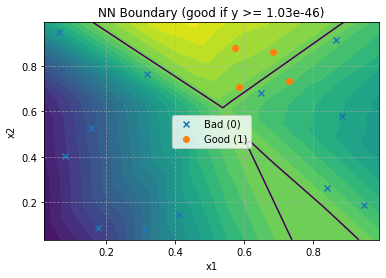

In [7]:
X = combined_func1_inputs
Y = combined_func1_outputs
results = train_and_evaluate_nn_boundary(
    X, Y,
    label_method="quantile", q=0.80,   # good = top 20% of observed outputs
    # OR: label_method="threshold", tau=0.0  # good = y >= 0
    hidden=(32, 32),
    dropout=0.15,
    lr=1e-3,
    epochs=500,
    batch_size=8,
    patience=40
)

# Visualise boundary if 2D:
y_class_all, thr = make_good_bad_labels(Y, method="quantile", q=0.80)
plot_nn_decision_boundary_2d(
    X, y_class_all,
    results["model"], results["scaler"],
    title=f"NN Boundary (good if y >= {thr:.3g})"
)

In [6]:
# Function 2
print('Function 2')
# Load inputs from previous run
# Loads initial data
week_0_func2_inputs = np.load('./initial_data/function_2/initial_inputs.npy')
week_0_func2_outputs = np.load('./initial_data/function_2/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func2_inputs.shape}')
print(f'Shape of initial output data: {week_0_func2_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[1]}')
print(f'Week 2 inputs: {week_2_inputs[1]}')
print(f'Week 3 inputs: {week_3_inputs[1]}')
print(f'Week 4 inputs: {week_4_inputs[1]}')
print(f'Week 5 inputs: {week_5_inputs[1]}')
print(f'Week 6 inputs: {week_6_inputs[1]}')

combined_func2_inputs = np.vstack([
    week_0_func2_inputs,
    week_1_inputs[1],
    week_2_inputs[1],
    week_3_inputs[1],
    week_4_inputs[1],
    week_5_inputs[1],
    week_6_inputs[1]
])
print(f'Number of input data points: {len(combined_func2_inputs)}')
print('Combined input data')
print(combined_func2_inputs)

# Load outputs from previous run
week_func2_output = week_1_outputs[1]
combined_func2_outputs = np.concatenate([
    week_0_func2_outputs,
    [week_1_outputs[1]],
    [week_2_outputs[1]],
    [week_3_outputs[1]],
    [week_4_outputs[1]],
    [week_5_outputs[1]],
    [week_6_outputs[1]]
])
print(f'Number of output data points: {len(combined_func2_outputs)}')
print('Combined output data')
print(combined_func2_outputs)

# ---------- FUNCTION 2: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
kernel = ConstantKernel(1.0) * RBF(length_scale=(0.5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func2_inputs
y = combined_func2_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1)]        # 2-D inputs
# bounds=[(0, 1), (0, 1), (0, 1)]        # 3-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ei"
xi = 0.0001
        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, xi),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

Function 2
Shape of initial input data: (10, 2)
Shape of initial output data: (10,)
Week 1 inputs: [0.224164 0.812385]
Week 2 inputs: [0.712637 0.921564]
Week 3 inputs: [0.699637 0.928564]
Week 4 inputs: [0.83604  0.696071]
Week 5 inputs: [0.388677 0.271349]
Week 6 inputs: [0.593592 0.679102]
Number of input data points: 16
Combined input data
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.224164   0.812385  ]
 [0.712637   0.921564  ]
 [0.699637   0.928564  ]
 [0.83604    0.696071  ]
 [0.388677   0.271349  ]
 [0.593592   0.679102  ]]
Number of output data points: 16
Combined output data
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.04614597  0.57283728
  0.49978779  0.20657541  0.01641866  0.06836721]
Nex

----- GOOD/BAD LABELING -----
Label method: quantile
Threshold used: 0.499788
Class balance (good=1): 0.250

----- TEST METRICS (Boundary Approximation) -----
Accuracy:  0.800
Precision: 0.000
Recall:    0.000
F1:        0.000
ROC AUC:   0.750

Confusion Matrix:
 [[4 0]
 [1 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



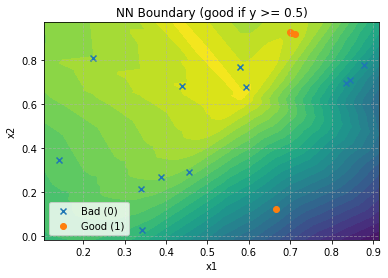

In [9]:
X = combined_func2_inputs
Y = combined_func2_outputs
results = train_and_evaluate_nn_boundary(
    X, Y,
    label_method="quantile", q=0.80,   # good = top 20% of observed outputs
    # OR: label_method="threshold", tau=0.0  # good = y >= 0
    hidden=(32, 32),
    dropout=0.15,
    lr=1e-3,
    epochs=500,
    batch_size=8,
    patience=40
)

# Visualise boundary if 2D:
y_class_all, thr = make_good_bad_labels(Y, method="quantile", q=0.80)
plot_nn_decision_boundary_2d(
    X, y_class_all,
    results["model"], results["scaler"],
    title=f"NN Boundary (good if y >= {thr:.3g})"
)

In [7]:
# Function 3
print('Function 3')

week_0_func3_inputs = np.load('./initial_data/function_3/initial_inputs.npy')
week_0_func3_outputs = np.load('./initial_data/function_3/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func3_inputs.shape}')
print(f'Shape of initial output data: {week_0_func3_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[2]}')
print(f'Week 2 inputs: {week_2_inputs[2]}')
print(f'Week 3 inputs: {week_3_inputs[2]}')
print(f'Week 4 inputs: {week_4_inputs[2]}')
print(f'Week 5 inputs: {week_5_inputs[2]}')
print(f'Week 6 inputs: {week_6_inputs[2]}')

combined_func3_inputs = np.vstack([
    week_0_func3_inputs,
    week_1_inputs[2],
    week_2_inputs[2],
    week_3_inputs[2],
    week_4_inputs[2],
    week_5_inputs[2],
    week_6_inputs[2]
])

print(f'Number of input data points: {len(combined_func3_inputs)}')
print('Combined input data')
print(combined_func3_inputs)

combined_func3_outputs = np.concatenate([
    week_0_func3_outputs,
    [week_1_outputs[2]],
    [week_2_outputs[2]],
    [week_3_outputs[2]],
    [week_4_outputs[2]],
    [week_5_outputs[2]],
    [week_6_outputs[2]]
])

print(f'Number of output data points: {len(combined_func3_outputs)}')
print('Combined output data')
print(combined_func3_outputs)

# ---------- FUNCTION 3: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
kernel = ConstantKernel(1.0) * RBF(length_scale=(0.5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func3_inputs
y = combined_func3_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1)]        # 3-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ucb"
kappa = 5.0
       
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, kappa),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

Function 3
Shape of initial input data: (15, 3)
Shape of initial output data: (15,)
Week 1 inputs: [0.830919 0.158523 0.528406]
Week 2 inputs: [0.765104 0.052672 0.438597]
Week 3 inputs: [0.123457 0.876543 0.5     ]
Week 4 inputs: [0.447658 0.395195 0.505344]
Week 5 inputs: [1.       0.136717 0.850593]
Week 6 inputs: [0.7536 1.     1.    ]
Number of input data points: 21
Combined input data
[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]
 [0.830919   0.158523   0.528406  ]
 [0.765104   0.052672   0.4385

In [8]:
# Function 4
print('Function 4')

week_0_func4_inputs = np.load('./initial_data/function_4/initial_inputs.npy')
week_0_func4_outputs = np.load('./initial_data/function_4/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func4_inputs.shape}')
print(f'Shape of initial output data: {week_0_func4_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[3]}')
print(f'Week 2 inputs: {week_2_inputs[3]}')
print(f'Week 3 inputs: {week_3_inputs[3]}')
print(f'Week 4 inputs: {week_4_inputs[3]}')
print(f'Week 5 inputs: {week_5_inputs[3]}')
print(f'Week 6 inputs: {week_6_inputs[3]}')

combined_func4_inputs = np.vstack([
    week_0_func4_inputs,
    week_1_inputs[3],
    week_2_inputs[3],
    week_3_inputs[3],
    week_4_inputs[3],
    week_5_inputs[3],
    week_6_inputs[3]
])

print(f'Number of input data points: {len(combined_func4_inputs)}')
print('Combined input data')
print(combined_func4_inputs)

combined_func4_outputs = np.concatenate([
    week_0_func4_outputs,
    [week_1_outputs[3]],
    [week_2_outputs[3]],
    [week_3_outputs[3]],
    [week_4_outputs[3]],
    [week_5_outputs[3]],
    [week_6_outputs[3]]

])

print(f'Number of output data points: {len(combined_func4_outputs)}')
print('Combined output data')
print(combined_func4_outputs)

# ---------- FUNCTION 4: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
kernel = ConstantKernel(1.0) * RBF(length_scale=(0.5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func4_inputs
y = combined_func4_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1)]        # 4-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ei"
xi = 0.01
        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, xi),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

Function 4
Shape of initial input data: (30, 4)
Shape of initial output data: (30,)
Week 1 inputs: [0.912533 0.052672 0.771239 0.219812]
Week 2 inputs: [0.380965 0.771701 0.089479 0.536968]
Week 3 inputs: [0.230785 0.914568 0.102938 0.657322]
Week 4 inputs: [0.422706 0.385497 0.37529  0.410833]
Week 5 inputs: [0.908266 0.239562 0.144895 0.489453]
Week 6 inputs: [0.370348 0.379959 0.430216 0.444351]
Number of input data points: 36
Combined input data
[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.476

In [9]:
# Function 5
print('Function 5')

week_0_func5_inputs = np.load('./initial_data/function_5/initial_inputs.npy')
week_0_func5_outputs = np.load('./initial_data/function_5/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func5_inputs.shape}')
print(f'Shape of initial output data: {week_0_func5_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[4]}')
print(f'Week 2 inputs: {week_2_inputs[4]}')
print(f'Week 3 inputs: {week_3_inputs[4]}')
print(f'Week 4 inputs: {week_4_inputs[4]}')
print(f'Week 5 inputs: {week_5_inputs[4]}')
print(f'Week 6 inputs: {week_6_inputs[4]}')

combined_func5_inputs = np.vstack([
    week_0_func5_inputs,
    week_1_inputs[4],
    week_2_inputs[4],
    week_3_inputs[4],
    week_4_inputs[4],
    week_5_inputs[4],
    week_6_inputs[4]
])

print(f'Number of input data points: {len(combined_func5_inputs)}')
print('Combined input data')
print(combined_func5_inputs)

combined_func5_outputs = np.concatenate([
    week_0_func5_outputs,
    [week_1_outputs[4]],
    [week_2_outputs[4]],
    [week_3_outputs[4]],
    [week_4_outputs[4]],
    [week_5_outputs[4]],
    [week_6_outputs[4]]
])

print(f'Number of output data points: {len(combined_func5_outputs)}')
print('Combined output data')
print(combined_func5_outputs)

# ---------- FUNCTION 5: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
kernel = ConstantKernel(1.0) * RBF(length_scale=(0.5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func5_inputs
y = combined_func5_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1)]        # 4-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ei"
xi = 0.00001
        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, xi),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

Function 5
Shape of initial input data: (20, 4)
Shape of initial output data: (20,)
Week 1 inputs: [0.234189 0.83648  0.884484 0.873516]
Week 2 inputs: [0.219189 0.85148  0.874484 0.883516]
Week 3 inputs: [0.214189 0.85648  0.869484 0.888516]
Week 4 inputs: [0.157706 0.912326 0.830158 0.925715]
Week 5 inputs: [0.115614 0.955641 0.820859 0.938174]
Week 6 inputs: [0.169493 0.556801 0.936155 0.69603 ]
Number of input data points: 26
Combined input data
[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.348

In [20]:
# Function 6
print('Function 6')

week_0_func6_inputs = np.load('./initial_data/function_6/initial_inputs.npy')
week_0_func6_outputs = np.load('./initial_data/function_6/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func6_inputs.shape}')
print(f'Shape of initial output data: {week_0_func6_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[5]}')
print(f'Week 2 inputs: {week_2_inputs[5]}')
print(f'Week 3 inputs: {week_3_inputs[5]}')
print(f'Week 4 inputs: {week_4_inputs[5]}')
print(f'Week 5 inputs: {week_5_inputs[5]}')
print(f'Week 6 inputs: {week_6_inputs[5]}')

combined_func6_inputs = np.vstack([
    week_0_func6_inputs,
    week_1_inputs[5],
    week_2_inputs[5],
    week_3_inputs[5],
    week_4_inputs[5],
    week_5_inputs[5],
    week_6_inputs[5]
])

print(f'Number of input data points: {len(combined_func6_inputs)}')
print('Combined input data')
print(combined_func6_inputs)

combined_func6_outputs = np.concatenate([
    week_0_func6_outputs,
    [week_1_outputs[5]],
    [week_2_outputs[5]],
    [week_3_outputs[5]],
    [week_4_outputs[5]],
    [week_5_outputs[5]],
    [week_6_outputs[5]]
])

print(f'Number of output data points: {len(combined_func6_outputs)}')
print('Combined output data')
print(combined_func6_outputs)

# ---------- FUNCTION 6: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
# kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=(0.5, (1e-2, 1e2)))

# This allows for Automatic Relevance Determination (ARD)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.5] * 5, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func6_inputs
y = combined_func6_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]        # 5-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ucb"
kappa = 3
        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, kappa),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

Function 6
Shape of initial input data: (20, 5)
Shape of initial output data: (20,)
Week 1 inputs: [0.490808 0.618683 0.277824 0.900494 0.106596]
Week 2 inputs: [0.114755 0.697421 0.354179 0.887624 0.589139]
Week 3 inputs: [0.051235 0.987654 0.43211  0.123457 0.765432]
Week 4 inputs: [0.275401 0.       0.568079 1.       0.121326]
Week 5 inputs: [0.568442 0.       1.       1.       1.      ]
Week 6 inputs: [0.366464 0.316099 1.       1.       0.      ]
Number of input data points: 26
Combined input data
[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02

In [10]:
# Function 7
print('Function 7')

week_0_func7_inputs = np.load('./initial_data/function_7/initial_inputs.npy')
week_0_func7_outputs = np.load('./initial_data/function_7/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func7_inputs.shape}')
print(f'Shape of initial output data: {week_0_func7_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[6]}')
print(f'Week 2 inputs: {week_2_inputs[6]}')
print(f'Week 3 inputs: {week_3_inputs[6]}')
print(f'Week 4 inputs: {week_4_inputs[6]}')
print(f'Week 5 inputs: {week_5_inputs[6]}')
print(f'Week 6 inputs: {week_6_inputs[6]}')

combined_func7_inputs = np.vstack([
    week_0_func7_inputs,
    week_1_inputs[6],
    week_2_inputs[6],
    week_3_inputs[6],
    week_4_inputs[6],
    week_5_inputs[6],
    week_6_inputs[6]
])

print(f'Number of input data points: {len(combined_func7_inputs)}')
print('Combined input data')
print(combined_func7_inputs)

combined_func7_outputs = np.concatenate([
    week_0_func7_outputs,
    [week_1_outputs[6]],
    [week_2_outputs[6]],
    [week_3_outputs[6]],
    [week_4_outputs[6]],
    [week_5_outputs[6]],
    [week_6_outputs[6]]
])

print(f'Number of output data points: {len(combined_func7_outputs)}')
print('Combined output data')
print(combined_func7_outputs)

# ---------- FUNCTION 7: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
kernel = ConstantKernel(1.0) * RBF(length_scale=(0.5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func7_inputs
y = combined_func7_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]        # 6-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ei"
xi = 0.001

        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, xi),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

Function 7
Shape of initial input data: (30, 6)
Shape of initial output data: (30,)
Week 1 inputs: [0.067896 0.486672 0.255422 0.215118 0.427428 0.72097 ]
Week 2 inputs: [0.070896 0.484672 0.259422 0.216118 0.427428 0.72297 ]
Week 3 inputs: [0.071896 0.483672 0.261422 0.217118 0.426428 0.72497 ]
Week 4 inputs: [0.124679 0.389027 0.389012 0.23686  0.379036 0.802247]
Week 5 inputs: [0.134015 0.028783 0.755137 0.62031  0.70408  0.212964]
Week 6 inputs: [0.123574 0.270452 0.482301 0.208163 0.330398 0.872733]
Number of input data points: 36
Combined input data
[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 

In [11]:
# Function 8
print('Function 8')

week_0_func8_inputs = np.load('./initial_data/function_8/initial_inputs.npy')
week_0_func8_outputs = np.load('./initial_data/function_8/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func8_inputs.shape}')
print(f'Shape of initial output data: {week_0_func8_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[7]}')
print(f'Week 2 inputs: {week_2_inputs[7]}')
print(f'Week 3 inputs: {week_3_inputs[7]}')
print(f'Week 4 inputs: {week_4_inputs[7]}')
print(f'Week 5 inputs: {week_5_inputs[7]}')
print(f'Week 6 inputs: {week_6_inputs[7]}')

combined_func8_inputs = np.vstack([
    week_0_func8_inputs,
    week_1_inputs[7],
    week_2_inputs[7],
    week_3_inputs[7],
    week_4_inputs[7],
    week_5_inputs[7],
    week_6_inputs[7]
])

print(f'Number of input data points: {len(combined_func8_inputs)}')
print('Combined input data')
print(combined_func8_inputs)

combined_func8_outputs = np.concatenate([
    week_0_func8_outputs,
    [week_1_outputs[7]],
    [week_2_outputs[7]],
    [week_3_outputs[7]],
    [week_4_outputs[7]],
    [week_5_outputs[7]],
    [week_6_outputs[7]]
])

print(f'Number of output data points: {len(combined_func8_outputs)}')
print('Combined output data')
print(combined_func8_outputs)

# ---------- FUNCTION 8: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
kernel = ConstantKernel(1.0) * RBF(length_scale=(0.5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func8_inputs
y = combined_func8_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]        # *-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ucb"
kappa = 2.5
        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, kappa),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

Function 8
Shape of initial input data: (40, 8)
Shape of initial output data: (40,)
Week 1 inputs: [0.061447 0.062956 0.029929 0.036786 0.407935 0.795055 0.496307 0.888085]
Week 2 inputs: [0.062447 0.061956 0.030929 0.035786 0.408935 0.794055 0.497307 0.887085]
Week 3 inputs: [0.063447 0.060956 0.031929 0.034786 0.409935 0.793055 0.498307 0.886085]
Week 4 inputs: [0.077447 0.21029  0.114032 0.159535 0.695924 0.531316 0.178973 0.57168 ]
Week 5 inputs: [0.127008 0.292876 0.06967  0.277582 0.553407 0.547258 0.220835 0.443146]
Week 6 inputs: [0.3191   0.828915 0.037008 0.59627  0.230009 0.120567 0.076953 0.696289]
Number of input data points: 46
Combined input data
[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.093